In [2]:
from infection import Simulation, Params, AgentTypeRatio, AgentState, Agent
import numpy as np
import matplotlib.pyplot as plt
from params import DAY_HOURS, _TransitionTable, TRASITION_TABLE

In [3]:
example_params = Params(
    T=10,
    N=5000,
    alpha=3,
    exposed=13,
    ratios=AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=1,
    primary_care=5,
    hospitals=1,
    other_working_places=2,
    public_places=6,
)

In [4]:
model = Simulation(params=example_params, public_events=[], seed=13)
model.init()

In [5]:
model.run(T=100*DAY_HOURS, dt=1*DAY_HOURS)

In [6]:
inf_progress = {f: [0] for f in AgentState}
for state in model.get_stats()["Agent_fraction"]:
    agents_counts = state["frac"]
    for k in inf_progress:
        if k in agents_counts:
            inf_progress[k].append(agents_counts[k])
        else:
            inf_progress[k].append(0)


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/ziverael/Documents/Studies/Studies2/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/ziverael/Documents/Studies/Studies2/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniBol.ttf', name='STIXNonUnicode', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='

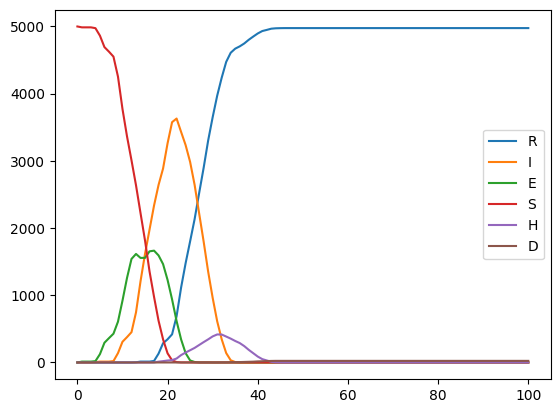

In [7]:
I = (
    np.array(inf_progress[AgentState.I0]) +
    np.array(inf_progress[AgentState.I1]) +
    np.array(inf_progress[AgentState.I2])
)
plt.plot(inf_progress[AgentState.R], label="R")
plt.plot(I, label="I")
plt.plot(inf_progress[AgentState.E], label="E")
inf_progress[AgentState.S][0] = 5000
plt.plot(inf_progress[AgentState.S], label="S")
plt.plot(inf_progress[AgentState.H], label="H")
plt.plot(inf_progress[AgentState.D], label="D")
plt.legend()

In [8]:
#do zmiany parametrów
custom_transition_table = _TransitionTable(
    SE=0.4,
    I0I1=0.4,
    I0I2=0.6,
    I2R=0.83,
    I2H=0.17,
    HR=0.951,
    HD=0.049,
)
Agent.transition_table = custom_transition_table

In [9]:
model = Simulation(params=example_params, public_events=[], seed=13)
model.init()

In [10]:
model.run(T=100*DAY_HOURS, dt=1*DAY_HOURS)

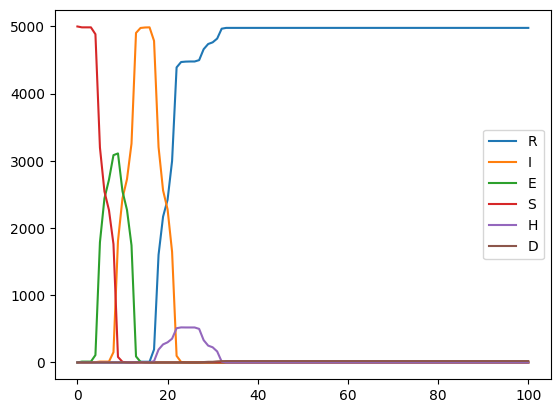

In [11]:
inf_progress = {f: [0] for f in AgentState}
for state in model.get_stats()["Agent_fraction"]:
    agents_counts = state["frac"]
    for k in inf_progress:
        if k in agents_counts:
            inf_progress[k].append(agents_counts[k])
        else:
            inf_progress[k].append(0)

I = (
    np.array(inf_progress[AgentState.I0]) +
    np.array(inf_progress[AgentState.I1]) +
    np.array(inf_progress[AgentState.I2])
)
plt.plot(inf_progress[AgentState.R], label="R")
plt.plot(I, label="I")
plt.plot(inf_progress[AgentState.E], label="E")
inf_progress[AgentState.S][0] = 5000
plt.plot(inf_progress[AgentState.S], label="S")
plt.plot(inf_progress[AgentState.H], label="H")
plt.plot(inf_progress[AgentState.D], label="D")
plt.legend()

In [ ]:
#przywrócenie domyślnych parametrów
Agent.transition_table = TRASITION_TABLE

NameError: name 'TRANSITION_TABLE' is not defined